In [1]:
%pip install bayesian-optimization
%pip install hyperopt
%pip install smac
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt
import seaborn as sns
from bayes_opt import BayesianOptimization
from hyperopt import fmin, tpe, hp, STATUS_OK, Trials
from ConfigSpace import ConfigurationSpace, Float
from smac import HyperparameterOptimizationFacade, Scenario



     --------------------------------------- 12.6/12.6 MB 13.9 MB/s eta 0:00:00
     ---------------------------------------- 8.3/8.3 MB 12.3 MB/s eta 0:00:00
     ---------------------------------------- 36.6/36.6 MB 9.0 MB/s eta 0:00:00
     -------------------------------------- 306.1/306.1 kB 6.3 MB/s eta 0:00:00
     -------------------------------------- 474.0/474.0 kB 5.9 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


     -------------------------------------- 973.5/973.5 kB 7.7 MB/s eta 0:00:00
     ---------------------------------------- 2.1/2.1 MB 12.0 MB/s eta 0:00:00
     ---------------------------------------- 80.2/80.2 kB 4.4 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


     -------------------------------------- 278.1/278.1 kB 2.5 MB/s eta 0:00:00
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
     -------------------------------------- 117.6/117.6 kB 6.7 MB/s eta 0:00:00
     ---------------------------------------- 1.5/1.5 MB 13.5 MB/s eta 0:00:00
     ---------------------------------------- 52.0/52.0 kB ? eta 0:00:00
     ---------------------------------------- 47.4/47.4 kB ? eta 0:00:00
     -------------------------------------- 278.0/278.0 kB 8.6 MB/s eta 0:00:00
     ---------------------------------------- 122.8/122.8 kB ? eta 0:00:00
     ---------------------------------------- 72.2/72.2 kB ? eta 0:00:00
     ---------------------------------------- 1.0/1.0 MB 


[notice] A new release of pip available: 22.3.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


ModuleNotFoundError: No module named 'matplotlib'

## Patient response function and Bayesian optimzer algorithm functions.

In [ ]:
import pandas as pd
import numpy as np
from bayes_opt import BayesianOptimization
from hyperopt import fmin, tpe, hp, STATUS_OK, Trials
from ConfigSpace import ConfigurationSpace, Float
from smac import HyperparameterOptimizationFacade, Scenario

# Default response-surface family: 2 optima, baseline smoothness, no added measurement noise
BASELINE_FAMILY = {
    'name': 'baseline_2optima',
    'num_optima': 2,
    'spread_scale': 1.0,
    'noise_std': 0.0,
    'noise_type': 'gaussian',
}


def generate_patient_profile(patient_seed: int, family: dict = BASELINE_FAMILY) -> dict:
    """Draws one unique synthetic patient's response landscape for a given surface family, independent of any optimizer's own RNG."""
    rng = np.random.default_rng(patient_seed)

    base_optima = [(10.0, 500.0), (25.0, 100.0)]
    num_optima = family['num_optima']
    optima = []
    for idx in range(num_optima):
        if idx < len(base_optima):
            opt_f, opt_w = base_optima[idx]
        else:
            # extra optima (beyond the base two) are anchored at random locations in the search domain
            opt_f = rng.uniform(5.0, 50.0)
            opt_w = rng.uniform(50.0, 600.0)
        new_f = opt_f + rng.uniform(-1.5, 1.5)
        new_w = opt_w + rng.uniform(-40.0, 40.0)
        optima.append((new_f, new_w))

    spread_scale = family['spread_scale']

    return {
        'patient_seed': patient_seed,
        'surface_family': family['name'],
        'ideal_amp_pup': rng.normal(4.4, 0.15),
        'amp_spread_pup': rng.uniform(0.4, 0.6),
        'ideal_amp_hrv': rng.normal(4.0, 0.15),
        'amp_spread_hrv': rng.uniform(0.3, 0.5),
        'optima': optima,
        'freq_spread': rng.uniform(4.0, 6.0) * spread_scale,
        'width_spread': rng.uniform(80.0, 120.0) * spread_scale,
        'noise_std': family['noise_std'],
        'noise_type': family['noise_type'],
    }


def run_optimization_comparison(num_simulation_trials: int, random_seed, search_boundaries: dict, patient_profile: dict) -> pd.DataFrame:

    # Patient-specific landscape (unique per simulated patient, not per optimizer run)
    ideal_amp_pup = patient_profile['ideal_amp_pup']
    amp_spread_pup = patient_profile['amp_spread_pup']
    ideal_amp_hrv = patient_profile['ideal_amp_hrv']
    amp_spread_hrv = patient_profile['amp_spread_hrv']
    optima = patient_profile['optima']
    freq_spread = patient_profile['freq_spread']
    width_spread = patient_profile['width_spread']

    # Measurement noise is sampled from its own RNG, independent of both patient generation and optimizer randomness
    noise_rng = np.random.default_rng((patient_profile['patient_seed'], random_seed))

    def realistic_patient_curve(amplitude, frequency, pulse_width):

        # We calculate response based on proximity to the optimal (Freq, Width) pairs
        def get_interdependence_score(f, w):
            scores = []
            for (opt_f, opt_w) in optima:
                dist = (((f - opt_f)**2 / (2 * freq_spread**2)) +
                        ((w - opt_w)**2 / (2 * width_spread**2)))
                scores.append(np.exp(-dist))
            return max(scores) # Return strongest response

        inter_score = get_interdependence_score(frequency, pulse_width)

        # Pupillometry Calculation
        amp_comp_pup = np.exp(-((amplitude - ideal_amp_pup)**2) / (2 * amp_spread_pup**2))
        pup_score = 100 * amp_comp_pup * inter_score

        # HRV Calculation
        amp_comp_hrv = np.exp(-((amplitude - ideal_amp_hrv)**2) / (2 * amp_spread_hrv**2))
        hrv_score = 100 * amp_comp_hrv * inter_score

        return {'pup': max(0, pup_score), 'hrv': max(0, hrv_score)}

    def multi_objective_wrapper(amplitude, frequency, pulse_width):
        results = realistic_patient_curve(amplitude, frequency, pulse_width)
        w_pup, w_hrv = 0.5, 0.5
        score = w_pup * results['pup'] + w_hrv * results['hrv']

        noise_std = patient_profile['noise_std']
        if noise_std > 0:
            if patient_profile['noise_type'] == 't':
                score += noise_rng.standard_t(df=3) * noise_std
            else:
                score += noise_rng.normal(0, noise_std)
        return score

    # --- Bayesian Optimization ---
    optimizer_multi = BayesianOptimization(
        f=multi_objective_wrapper,
        pbounds=search_boundaries,
        random_state=random_seed,
        verbose=0
    )
    print(f"\n--- Starting Bayesian Optimization ({num_simulation_trials} iterations) ---")
    optimizer_multi.maximize(init_points=max(1, num_simulation_trials // 10), n_iter=num_simulation_trials - max(1, num_simulation_trials // 10))

    # --- TPE Optimization ---
    def objective_tpe(params):
        score = multi_objective_wrapper(params['amplitude'], params['frequency'], params['pulse_width'])
        return {'loss': -score, 'status': STATUS_OK}

    space = {
        'amplitude': hp.uniform('amplitude', search_boundaries['amplitude'][0], search_boundaries['amplitude'][1]),
        'frequency': hp.uniform('frequency', search_boundaries['frequency'][0], search_boundaries['frequency'][1]),
        'pulse_width': hp.uniform('pulse_width', search_boundaries['pulse_width'][0], search_boundaries['pulse_width'][1])
    }
    trials = Trials()
    print(f"\n--- Starting TPE Optimization ({num_simulation_trials} iterations) ---")
    fmin(fn=objective_tpe, space=space, algo=tpe.suggest, max_evals=num_simulation_trials, trials=trials, rstate=np.random.default_rng(random_seed))

    # --- SMAC Optimization ---
    configspace = ConfigurationSpace(seed=random_seed)
    configspace.add_hyperparameters([
        Float('amplitude', bounds=search_boundaries['amplitude']),
        Float('frequency', bounds=search_boundaries['frequency']),
        Float('pulse_width', bounds=search_boundaries['pulse_width']),
    ])

    def objective_smac(config, seed=random_seed):
        return -multi_objective_wrapper(
            float(config['amplitude']),
            float(config['frequency']),
            float(config['pulse_width']),
        )

    print(f"\n--- Starting SMAC Optimization ({num_simulation_trials} iterations) ---")
    scenario = Scenario(
        configspace,
        deterministic=patient_profile['noise_std'] == 0,
        n_trials=num_simulation_trials,
        seed=random_seed,
    )
    smac = HyperparameterOptimizationFacade(scenario, objective_smac)
    incumbent = smac.optimize()
    smac_score = -smac.runhistory.get_cost(incumbent)

    # --- Random Search ---
    random_search_rng = np.random.default_rng(random_seed)
    best_random_score = -np.inf
    best_random_params = {}
    print(f"\n--- Starting Random Search Optimization ({num_simulation_trials} iterations) ---")
    for _ in range(num_simulation_trials):
        a, f, w = [random_search_rng.uniform(search_boundaries[k][0], search_boundaries[k][1]) for k in ['amplitude', 'frequency', 'pulse_width']]
        current_score = multi_objective_wrapper(a, f, w)
        if current_score > best_random_score:
            best_random_score = current_score
            best_random_params = {'amplitude': a, 'frequency': f, 'pulse_width': w}

    comparison_data = {
        'Method': ['Bayesian Optimization', 'TPE Optimization', 'SMAC Optimization', 'Random Search'],
        'Surface Family': [patient_profile['surface_family']] * 4,
        'Patient Seed': [patient_profile['patient_seed']] * 4,
        'Algorithm Seed': [random_seed] * 4,
        'Best Combined Score': [optimizer_multi.max['target'], -trials.best_trial['result']['loss'], smac_score, best_random_score],
        'Optimal Amplitude (mA)': [optimizer_multi.max['params']['amplitude'], trials.argmin['amplitude'], float(incumbent['amplitude']), best_random_params['amplitude']],
        'Optimal Frequency (Hz)': [optimizer_multi.max['params']['frequency'], trials.argmin['frequency'], float(incumbent['frequency']), best_random_params['frequency']],
        'Optimal Pulse Width (us)': [optimizer_multi.max['params']['pulse_width'], trials.argmin['pulse_width'], float(incumbent['pulse_width']), best_random_params['pulse_width']]
    }
    return pd.DataFrame(comparison_data)


### Visualizing the 3D Interaction Landscape
This plot illustrates the two 'Gaussian hills' created by the `inter_score` calculation, representing the optimal (Frequency, Pulse Width) pairs.

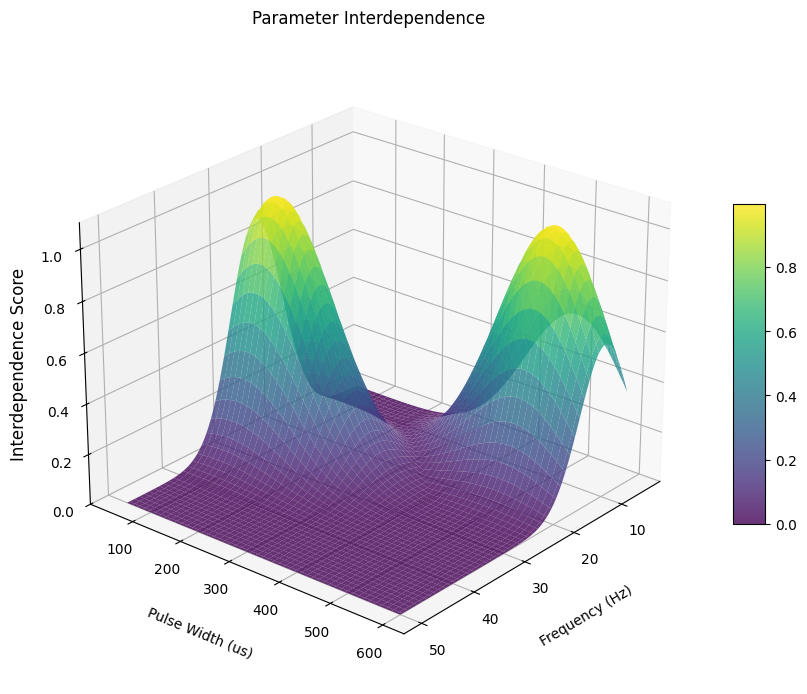

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Define parameters based on your model
optima = [(10.0, 500.0), (25.0, 100.0)]
freq_spread, width_spread = 5.0, 100.0

# Create a grid of Frequency and Pulse Width values
freq_range = np.linspace(5, 50, 100)
width_range = np.linspace(50, 600, 100)
F, W = np.meshgrid(freq_range, width_range)

# Calculate inter_score for the grid
def get_score_grid(f, w):
    scores = []
    for (opt_f, opt_w) in optima:
        dist = (((f - opt_f)**2 / (2 * freq_spread**2)) +
                ((w - opt_w)**2 / (2 * width_spread**2)))
        scores.append(np.exp(-dist))
    return np.maximum(scores[0], scores[1])

Z = get_score_grid(F, W)


fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(F, W, Z, cmap='viridis', edgecolor='none', alpha=0.8)
ax.view_init(elev=25, azim=40)
ax.dist = 12
ax.set_zlim(0, 1.1)


ax.set_xlabel('Frequency (Hz)', labelpad=15)
ax.set_ylabel('Pulse Width (us)', labelpad=15)

ax.text2D(-0.06, 0.5, "Interdependence Score", transform=ax.transAxes,
          rotation=90, fontsize=12, fontweight='normal', va='center')

ax.set_title('Parameter Interdependence', pad=15)

# Add colorbar
fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10)

plt.subplots_adjust(left=0.15, right=0.9, top=0.9, bottom=0.1)
plt.show()

Calculates the theoretical max of the combined scores.

In [ ]:
def calculate_theoretical_max():
    # Constants from your realistic_patient_curve function
    ideal_amp_pup = 4.4
    amp_spread_pup = 0.5
    ideal_amp_hrv = 4.0
    amp_spread_hrv = 0.4
    w_pup, w_hrv = 0.5, 0.5

    # Range of amplitudes to test
    amps = np.linspace(3.0, 5.0, 10000)

    # Calculate scores assuming inter_score = 1.0 (perfect freq/width match)
    pup_scores = 100 * np.exp(-((amps - ideal_amp_pup)**2) / (2 * amp_spread_pup**2))
    hrv_scores = 100 * np.exp(-((amps - ideal_amp_hrv)**2) / (2 * amp_spread_hrv**2))

    combined_scores = w_pup * pup_scores + w_hrv * hrv_scores

    max_idx = np.argmax(combined_scores)
    return combined_scores[max_idx], amps[max_idx]

theoretical_max, best_amp = calculate_theoretical_max()
print(f"Theoretical Maximum Combined Score: {theoretical_max:.2f}%")
print(f"Optimal Amplitude for this peak: {best_amp:.3f} mA")

Theoretical Maximum Combined Score: 90.73%
Optimal Amplitude for this peak: 4.151 mA


In [ ]:
num_trials_depth = 40
num_runs = 40

#taVNS search boundaires
taVNS_search_boundaries = {
    'amplitude': (3.0, 5.0),
    'frequency': (5.0, 50.0),
    'pulse_width': (50.0, 600.0)
}

all_comparison_results = []

for i in range(num_runs):
  print(f"\rRunning Optimization Comparison (Trial {i+1}/{num_runs})...", end="")
  # Distinct patient per trial (offset keeps it independent from the algorithm's own random_state=i)
  patient_profile = generate_patient_profile(patient_seed=10_000 + i, family=BASELINE_FAMILY)
  run_results = run_optimization_comparison(num_trials_depth, i, taVNS_search_boundaries, patient_profile)
  all_comparison_results.append(run_results)

final_comparison_df = pd.concat(all_comparison_results, ignore_index=True)

print("\n--- Combined Optimization Comparison Results ---")
display(final_comparison_df.head())
final_comparison_df.to_csv('combined_optimization_results.csv', index=False)


## Visualization of Optimization Comparison Results

This graph compares the performance and consistency of Bayesian Optimization, TPE, and SMAC based on their 'Best Combined Score' across multiple runs.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.boxplot(x='Method', y='Best Combined Score', data=final_comparison_df, palette='viridis', hue='Method', legend=False)
plt.title('Distribution of Best Combined Score by Optimization Method (Across Multiple Runs)')
plt.xlabel('Optimization Method')
plt.ylabel('Best Combined Score')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## Statistics about Optimization Methods


In [ ]:
import pandas as pd

# Group by 'Method' and calculate descriptive statistics for 'Best Combined Score'
score_stats = final_comparison_df.groupby('Method')['Best Combined Score'].agg(['mean', 'std', 'min', 'max']).reset_index()
print("\n--- Statistics for Best Combined Score ---")
display(score_stats)

# Calculate descriptive statistics for each optimal parameter
parameters = ['Optimal Amplitude (mA)', 'Optimal Frequency (Hz)', 'Optimal Pulse Width (us)']

all_param_stats = []
for param in parameters:
    param_stats = final_comparison_df.groupby('Method')[param].agg(['mean', 'std', 'min', 'max']).reset_index()
    param_stats['Parameter'] = param
    all_param_stats.append(param_stats)

# Concatenate all parameter statistics into a single DataFrame
final_param_stats_df = pd.concat(all_param_stats, ignore_index=True)

print("\n--- Statistics for Optimal Parameters ---")
display(final_param_stats_df)


## ANOVA Test for Optimization Methods


In [ ]:
from scipy import stats

# Extract the 'Best Combined Score' for each optimization method
bayesian_scores = final_comparison_df[final_comparison_df['Method'] == 'Bayesian Optimization']['Best Combined Score']
tpe_scores = final_comparison_df[final_comparison_df['Method'] == 'TPE Optimization']['Best Combined Score']
smac_scores = final_comparison_df[final_comparison_df['Method'] == 'SMAC Optimization']['Best Combined Score']
random_search_scores = final_comparison_df[final_comparison_df['Method'] == 'Random Search']['Best Combined Score']

# Perform one-way ANOVA including Random Search
f_statistic, p_value = stats.f_oneway(bayesian_scores, tpe_scores, smac_scores, random_search_scores)

print(f"--- ANOVA Results for Best Combined Score ---")
print(f"F-statistic: {f_statistic:.5f}")
print(f"P-value: {p_value:.5f}")

alpha = 0.05 # Significance level
if p_value < alpha:
    print(f"Conclusion: Reject the null hypothesis. There is a statistically significant difference (p < {alpha}) in the mean 'Best Combined Score' among the optimization methods.")
else:
    print(f"Conclusion: Fail to reject the null hypothesis. There is no statistically significant difference (p >= {alpha}) in the mean 'Best Combined Score' among the optimization methods.")

--- ANOVA Results for Best Combined Score ---
F-statistic: 7.59857
P-value: 0.00009
Conclusion: Reject the null hypothesis. There is a statistically significant difference (p < 0.05) in the mean 'Best Combined Score' among the optimization methods.


## Post-Hoc Analysis: Tukey's HSD Test

Since ANOVA indicates a statistically significant difference among the optimization methods, a post-hoc test is done to identify  which pairs of methods have statistically different mean Best Combined Score.

In [ ]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Combine all scores into a single array and create corresponding group labels
all_scores = pd.concat([bayesian_scores, tpe_scores, smac_scores, random_search_scores])
groups = ['Bayesian Optimization'] * len(bayesian_scores) + \
         ['TPE Optimization'] * len(tpe_scores) + \
         ['SMAC Optimization'] * len(smac_scores) + \
         ['Random Search'] * len(random_search_scores)

# Perform Tukey's HSD post-hoc test
tukey_result = pairwise_tukeyhsd(endog=all_scores, groups=groups, alpha=0.05)

print("--- Tukey's HSD Post-Hoc Test Results ---")
print(tukey_result)

# Results visualized
tukey_result.plot_simultaneous()
plt.title("Tukey's HSD - Best Combined Score")
plt.show()

## Sensitivity Analysis Across Response-Surface Families

The results above come from a single functional form (2 Gaussian optima, fixed smoothness, no measurement noise). To check whether the ranking of optimizers holds up beyond that one landscape, this section reruns the same comparison against several distinct synthetic "patient families" that vary the number of optima, the smoothness (spread) of the response peaks, and the measurement-noise distribution/magnitude. Each family still draws a fresh, unique simulated patient per trial (same design as above), just under different structural assumptions.


In [ ]:
SURFACE_FAMILIES = [
    {'name': 'baseline_2optima',    'num_optima': 2, 'spread_scale': 1.0, 'noise_std': 0.0, 'noise_type': 'gaussian'},
    {'name': 'sharp_peaks',         'num_optima': 2, 'spread_scale': 0.5, 'noise_std': 0.0, 'noise_type': 'gaussian'},
    {'name': 'smooth_broad',        'num_optima': 2, 'spread_scale': 2.0, 'noise_std': 0.0, 'noise_type': 'gaussian'},
    {'name': 'multi_optima_3',       'num_optima': 3, 'spread_scale': 1.0, 'noise_std': 0.0, 'noise_type': 'gaussian'},
    {'name': 'noisy_gaussian',       'num_optima': 2, 'spread_scale': 1.0, 'noise_std': 5.0, 'noise_type': 'gaussian'},
    {'name': 'noisy_heavy_tailed',   'num_optima': 2, 'spread_scale': 1.0, 'noise_std': 5.0, 'noise_type': 't'},
]

num_runs_per_family = 20

all_family_results = []
for family_index, family in enumerate(SURFACE_FAMILIES):
    # Each family gets its own independent pool of patients (seeds don't overlap across families)
    family_seed_offset = family_index * 100_000
    for i in range(num_runs_per_family):
        print(f"\rFamily '{family['name']}' - Trial {i+1}/{num_runs_per_family}...", end="")
        patient_profile = generate_patient_profile(patient_seed=family_seed_offset + i, family=family)
        run_results = run_optimization_comparison(num_trials_depth, i, taVNS_search_boundaries, patient_profile)
        all_family_results.append(run_results)

final_family_df = pd.concat(all_family_results, ignore_index=True)

print("\n--- Combined Results Across Surface Families ---")
display(final_family_df.head())
final_family_df.to_csv('surface_family_sensitivity_results.csv', index=False)


In [ ]:
family_method_means = final_family_df.groupby(['Surface Family', 'Method'])['Best Combined Score'].mean().unstack()

# Rank methods within each family (1 = highest mean score)
family_ranks = family_method_means.rank(axis=1, ascending=False)

print("--- Mean Best Combined Score by Surface Family and Method ---")
display(family_method_means)

print("\n--- Method Rank within Each Surface Family (1 = best) ---")
display(family_ranks)

top_method_per_family = family_ranks.idxmin(axis=1)
print("\n--- Top-Ranked Method per Surface Family ---")
display(top_method_per_family)


win_counts = top_method_per_family.value_counts()

print(f"\nOut of {len(SURFACE_FAMILIES)} surface families, each method ranked #1 in:")
print(win_counts.to_string())

In [ ]:
from google.colab import files
files.download('combined_optimization_results.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>